# Outlier Analysis

In this notebook, we analyze potential outliers in the Titanic dataset. Outliers are observations that are significantly different from the majority of the data.

The objective is not to automatically remove every outlier. Each unusual observation should be investigated to determine whether it is a data-entry error, a genuine observation, or an unusual but valid value.

This analysis uses the IQR method, Z-score method, Box Plot, and Scatter Plot to identify and understand potential outliers.

## 1. Dataset Loading

Before performing outlier analysis, we first load the Titanic dataset and identify the numerical variables that may contain unusual values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. What is an Outlier?

### Concept

An outlier is a data value that is significantly different from most other observations in a dataset.

### Example

If most passengers paid fares between 10 and 100, but one passenger paid a very high fare, that observation may be considered an outlier.

### Interpretation

An outlier does not always mean that the data is incorrect. It may represent a genuine but unusual observation.

### Insight

Therefore, detected outliers should be investigated before making any decision about removing or transforming them.

### AI/ML Relevance

Outliers can influence statistical analysis and Machine Learning models, especially models that are sensitive to extreme values.

In [2]:
example_data = [10, 15, 20, 25, 30, 200]

print("Example Data:", example_data)
print("Potential unusual value:", max(example_data))

Example Data: [10, 15, 20, 25, 30, 200]
Potential unusual value: 200


## Why Do Outliers Occur?

### Concept

Outliers can occur because of genuine rare observations, data-entry errors, measurement errors, or unusual events.

### Example

A very high Fare may represent a genuine expensive ticket. A negative Age, however, may indicate an incorrect data entry.

### Interpretation

The reason behind an unusual value should be investigated before deciding how to handle it.

### Insight

Not every outlier should be removed because genuine unusual observations may contain useful information.

### AI/ML Relevance

Incorrect handling of outliers can affect model performance and data quality.

In [3]:
print("Minimum Age:", df["Age"].min())
print("Maximum Age:", df["Age"].max())

print("\nMinimum Fare:", df["Fare"].min())
print("Maximum Fare:", df["Fare"].max())

Minimum Age: 0.42
Maximum Age: 80.0

Minimum Fare: 0.0
Maximum Fare: 512.3292


## Types of Outliers

### Univariate Outliers

A univariate outlier is unusual when one variable is analyzed independently.

Example: An unusually high Fare value.

### Multivariate Outliers

A multivariate outlier becomes unusual when the relationship between multiple variables is considered.

Example: An unusual combination of Age and Fare.

### AI/ML Relevance

Machine Learning models use multiple features together, so both univariate and multivariate outliers can be important.

In [4]:
df[["Age", "Fare", "Pclass"]].head()

,Age,Fare,Pclass
0,22.0,7.2500,3
1,38.0,71.2833,1
2,26.0,7.9250,3
3,35.0,53.1000,1
4,35.0,8.0500,3


## Numerical Variables for Outlier Analysis

### Concept

Outlier analysis is mainly performed on numerical variables because numerical values can be statistically compared with the overall distribution.

### Example

In the Titanic dataset, Age and Fare are useful variables for identifying unusual numerical observations.

### AI/ML Relevance

Identifying the correct numerical features helps us apply appropriate statistical outlier detection methods.

In [5]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')


## Univariate Outlier Detection Using Box Plot

### Concept

A box plot provides a visual summary of a numerical variable and can highlight potential outliers.

### Example

A Fare value located outside the main range of the box plot may be considered a potential outlier.

### Implementation

Box plots are created for Age and Fare.

### Interpretation

Observations outside the whiskers are potential outliers and should be investigated further.

### Insight

A box plot provides a quick visual method for identifying unusual observations.

### AI/ML Relevance

Visual outlier detection helps us understand the data before applying Machine Learning algorithms.

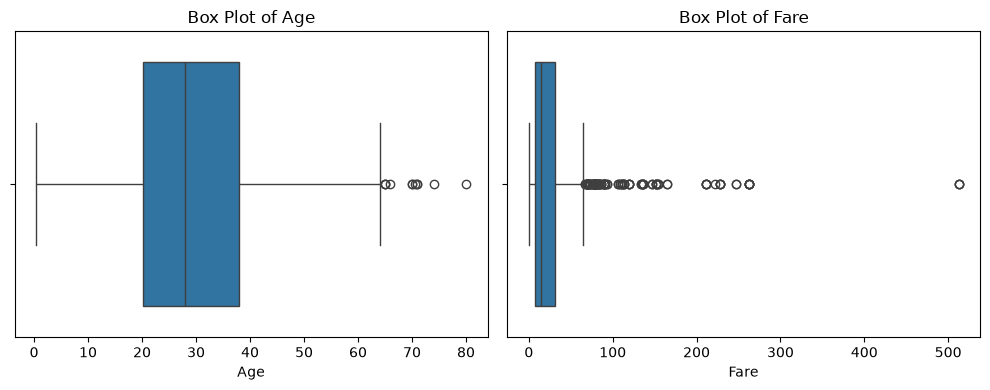

In [6]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["Age"])
plt.title("Box Plot of Age")

plt.subplot(1, 2, 2)
sns.boxplot(x=df["Fare"])
plt.title("Box Plot of Fare")

plt.tight_layout()
plt.show()

## Outlier Detection Using the IQR Method

### Concept

The Interquartile Range (IQR) method identifies potential outliers using the first quartile and third quartile.

### Formula

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

### Interpretation

Values below the lower bound or above the upper bound are considered potential outliers.

### AI/ML Relevance

The IQR method is a commonly used and robust technique for detecting numerical outliers.

In [7]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

age_outliers = df[
    (df["Age"] < lower_bound) |
    (df["Age"] > upper_bound)
]

print("Number of Age outliers:", len(age_outliers))

Number of Age outliers: 11


## IQR Analysis of Fare

### Concept

The same IQR method can be applied to the Fare column to identify unusually high or low ticket prices.

### Interpretation

High Fare values may represent genuine expensive tickets rather than data-entry errors.

### Insight

Detected Fare outliers should be investigated before removal.

### AI/ML Relevance

Highly skewed numerical variables may influence certain Machine Learning models and may require transformation.

In [8]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Number of Fare outliers:", len(fare_outliers))

Number of Fare outliers: 116


## Outlier Detection Using the Z-Score Method

### Concept

The Z-score measures how far a value is from the mean in terms of standard deviations.

A common rule is that values with an absolute Z-score greater than 3 may be considered potential outliers.

### Example

A Z-score of 4 indicates that the observation is approximately four standard deviations away from the mean.

### AI/ML Relevance

The Z-score method provides a statistical method for identifying unusually distant observations.

In [9]:
from scipy.stats import zscore

fare_data = df["Fare"].dropna()

z_scores = np.abs(zscore(fare_data))

z_outliers = fare_data[z_scores > 3]

print("Number of Fare outliers:", len(z_outliers))

Number of Fare outliers: 20


## Comparing IQR and Z-Score Results

### Concept

Different outlier detection techniques may identify different observations.

### Interpretation

The IQR method uses quartiles, while the Z-score method uses the mean and standard deviation.

### Insight

Using multiple methods provides a more complete understanding of potential outliers.

### AI/ML Relevance

The appropriate detection technique depends on the distribution and characteristics of the data.

In [10]:
print("IQR Fare Outliers:", len(fare_outliers))
print("Z-Score Fare Outliers:", len(z_outliers))

IQR Fare Outliers: 116
Z-Score Fare Outliers: 20


## Multivariate Outlier Analysis

### Concept

Multivariate outlier analysis considers more than one variable at the same time.

### Example

A passenger may have a reasonable Age and Fare individually, but the combination of both values may be unusual.

### Implementation

A scatter plot is used to study the relationship between Age and Fare.

### Interpretation

Points far away from the main cluster may represent potential multivariate outliers.

### AI/ML Relevance

Machine Learning models consider multiple features together, making multivariate outlier analysis important.

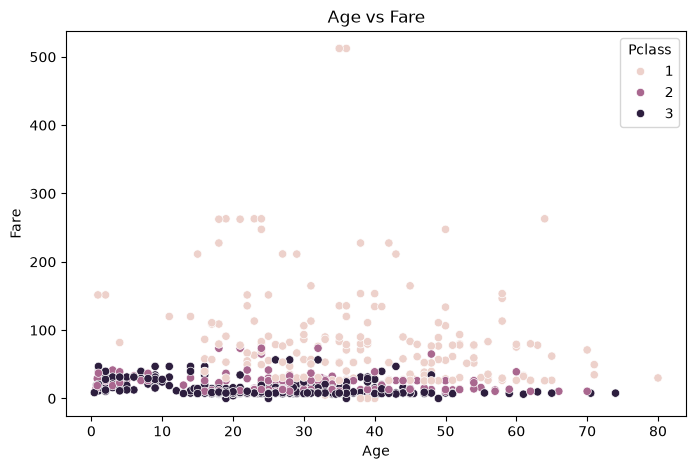

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Pclass"
)

plt.title("Age vs Fare")
plt.show()

## Investigating Detected Outliers

### Concept

After detecting potential outliers, we should investigate the actual observations.

### Questions to Consider

- Is it a genuine observation?
- Is it a data-entry error?
- Is it unusual but valid?
- Should it be removed?
- Should it be transformed?
- Should it be retained?

### Insight

Outlier detection is the beginning of the investigation, not the final decision.

In [12]:
fare_outliers[
    ["PassengerId", "Name", "Pclass", "Age", "Fare"]
].head(10)

,PassengerId,Name,Pclass,Age,Fare
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,71.2833
27,28,"Fortune, Mr. Charles Alexander",1,19.0,263.0000
31,32,"Spencer, Mrs. William Augustus (Marie Eugenie)",1,NaN,146.5208
34,35,"Meyer, Mr. Edgar Joseph",1,28.0,82.1708
52,53,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",1,49.0,76.7292
61,62,"Icard, Miss. Amelie",1,38.0,80.0000
62,63,"Harris, Mr. Henry Birkhardt",1,45.0,83.4750
72,73,"Hood, Mr. Ambrose Jr",2,21.0,73.5000
88,89,"Fortune, Miss. Mabel Helen",1,23.0,263.0000
102,103,"White, Mr. Richard Frasar",1,21.0,77.2875


## Outlier Treatment Decision

### Concept

Outliers should not be automatically removed.

### Interpretation

If an outlier is caused by a data-entry error, it may need to be corrected or removed. If it is a genuine but unusual observation, it should generally be retained.

### Insight

In the Titanic dataset, very high Fare values may represent genuine expensive tickets. Therefore, they should not be removed without evidence that they are incorrect.

### AI/ML Relevance

The treatment of outliers depends on the dataset and the requirements of the Machine Learning model.

In [13]:
df.nlargest(
    10,
    "Fare"
)[["PassengerId", "Name", "Pclass", "Fare"]]

,PassengerId,Name,Pclass,Fare
258,259,"Ward, Miss. Anna",1,512.3292
679,680,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292
737,738,"Lesurer, Mr. Gustave J",1,512.3292
27,28,"Fortune, Mr. Charles Alexander",1,263.0000
88,89,"Fortune, Miss. Mabel Helen",1,263.0000
341,342,"Fortune, Miss. Alice Elizabeth",1,263.0000
438,439,"Fortune, Mr. Mark",1,263.0000
311,312,"Ryerson, Miss. Emily Borie",1,262.3750
742,743,"Ryerson, Miss. Susan Parker ""Suzette""",1,262.3750
118,119,"Baxter, Mr. Quigg Edmond",1,247.5208


## Log Transformation

### Concept

Instead of removing genuine extreme values, a transformation can sometimes reduce their influence.

### Example

The Fare variable can be transformed using a logarithmic transformation.

### Interpretation

The original information is retained, while the effect of extremely large values may be reduced.

### AI/ML Relevance

Transformation can improve the distribution of highly skewed numerical features for some Machine Learning models.

In [14]:
df["Fare_Log"] = np.log1p(df["Fare"])

df[["Fare", "Fare_Log"]].head()

,Fare,Fare_Log
0,7.2500,2.110213
1,71.2833,4.280593
2,7.9250,2.188856
3,53.1000,3.990834
4,8.0500,2.202765


# Conclusion

In this notebook, potential outliers in the Titanic dataset were analyzed using box plots, the IQR method, the Z-score method, and scatter plots.

The analysis showed that potential outliers should not be automatically removed. Each unusual observation should be investigated to determine whether it is an error or a genuine observation.

For example, unusually high Fare values may represent genuine expensive tickets. Therefore, such observations may be retained or transformed depending on the requirements of the Machine Learning model.